In [ ]:
# from weather_data import get_weather_data

# Edge case: invalid location (should raise ValueError)
try:
    data = get_weather_data("", 3)
except Exception as e:
    print("Caught expected error for empty location:", e)

# Valid call but large days should clamp to 5
data = get_weather_data("Perth", 99)
print("Days returned:", len(data.get("weather", [])))

Caught expected error for empty location: location must be a non-empty string
Days returned: 3


In [ ]:
# from weather_data import get_weather_data

# Edge case: invalid location (should raise ValueError)
try:
    data = get_weather_data("", 3)
except Exception as e:
    print("Caught expected error for empty location:", e)

# Valid call but large days should clamp to 5
data = get_weather_data("Perth", 99)
print("Days returned:", len(data.get("weather", [])))

Caught expected error for empty location: location must be a non-empty string
Days returned: 3


# Table of Contents

- [Setup and Configuration](#setup)
- [Weather Data Functions](#weather-data)
- [Visualisation Functions](#viz)
- [Natural Language Processing](#nlp)
- [User Interface](#ui)
- [Main Application Logic](#main)
- [Testing and Examples](#testing)

# 📦 Setup and Configuration

<a id='setup'></a>
Install dependencies and set any API keys if needed.

In [ ]:
# If running in Colab, uncomment the following line:
# !pip install -q requests pyinputplus matplotlib pandas python-dateutil
import os, sys
from datetime import datetime
print("Environment OK. Python", sys.version)
!pip install -q pyinputplus requests matplotlib pandas python-dateutil

Environment OK. Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


# Weather Data Functions

<a id='weather-data'></a>
Core API retrieval with fallback to mock data.

In [ ]:
import os
import requests
from datetime import datetime, timedelta, UTC

WTTR_URL = "https://wttr.in/{loc}?format=j1"

# A small, realistic mock dataset used when API is unavailable
MOCK_DATA = {
    "current_condition": [{
        "temp_C": "22",
        "FeelsLikeC": "23",
        "windspeedKmph": "15",
        "humidity": "60",
        "weatherDesc": [{"value": "Partly cloudy"}]
    }],
    "weather": [
        {
            "date": (datetime.now(UTC)).strftime("%Y-%m-%d"),
            "hourly": [
                {"time": "0", "tempC": "18", "chanceofrain": "10"},
                {"time": "300", "tempC": "17", "chanceofrain": "10"},
                {"time": "600", "tempC": "19", "chanceofrain": "20"},
                {"time": "900", "tempC": "22", "chanceofrain": "20"},
                {"time": "1200", "tempC": "24", "chanceofrain": "30"},
                {"time": "1500", "tempC": "23", "chanceofrain": "20"},
                {"time": "1800", "tempC": "20", "chanceofrain": "15"},
                {"time": "2100", "tempC": "19", "chanceofrain": "10"}
            ],
            "maxtempC": "24",
            "mintempC": "16",
            "avgtempC": "20"
        },
        {
            "date": (datetime.now(UTC) + timedelta(days=1)).strftime("%Y-%m-%d"),
            "hourly": [
                {"time": "0", "tempC": "17", "chanceofrain": "20"},
                {"time": "300", "tempC": "16", "chanceofrain": "20"},
                {"time": "600", "tempC": "18", "chanceofrain": "25"},
                {"time": "900", "tempC": "21", "chanceofrain": "35"},
                {"time": "1200", "tempC": "23", "chanceofrain": "40"},
                {"time": "1500", "tempC": "22", "chanceofrain": "30"},
                {"time": "1800", "tempC": "19", "chanceofrain": "20"},
                {"time": "2100", "tempC": "18", "chanceofrain": "15"}
            ],
            "maxtempC": "23",
            "mintempC": "15",
            "avgtempC": "19"
        }
    ]
}

def _safe_get(d, path, default=None):
    cur = d
    try:
        for p in path:
            if isinstance(cur, list):
                cur = cur[p]
            else:
                cur = cur.get(p)
        return cur
    except Exception:
        return default

def get_weather_data(location, forecast_days=5):
    """
    Retrieve weather data for a specified location.

    Args:
        location (str): City or location name
        forecast_days (int): Number of days to forecast (1-5)

    Returns:
        dict: Weather data including current conditions and forecast
    """
    forecast_days = max(1, min(int(forecast_days or 5), 5))
    if not location or not isinstance(location, str):
        raise ValueError("location must be a non-empty string")
    url = WTTR_URL.format(loc=location.replace(' ', '+'))
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        raw = resp.json()
    except Exception:
        # Fallback to mock if offline or API fails
        raw = MOCK_DATA

    # Truncate to requested forecast_days if 'weather' present
    if 'weather' in raw:
        raw['weather'] = raw['weather'][:forecast_days]
    return raw

# Visualisation Functions

<a id='viz'></a>
Temperature trend and precipitation probability charts.

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime

def _extract_daily_series(weather_data):
    days = []
    tmax = []
    tmin = []
    prcp = []
    for day in weather_data.get("weather", []):
        days.append(day.get("date"))
        tmax.append(float(day.get("maxtempC", 0)))
        tmin.append(float(day.get("mintempC", 0)))
        # approximate precipitation chance as avg of hourly 'chanceofrain'
        hourly = day.get("hourly", [])
        if hourly:
            chances = [float(h.get("chanceofrain", 0)) for h in hourly if "chanceofrain" in h]
            prcp.append(sum(chances)/len(chances) if chances else 0.0)
        else:
            prcp.append(0.0)
    return days, tmax, tmin, prcp

def create_temperature_visualisation(weather_data, output_type='display'):
    """
    Create visualisation of temperature data.
    Args:
        weather_data (dict): The processed weather data
        output_type (str): 'display' or 'figure'
    Returns:
        matplotlib.figure.Figure or None
    """
    days, tmax, tmin, _ = _extract_daily_series(weather_data)
    fig, ax = plt.subplots()
    ax.plot(days, tmax, marker="o", label="Max Temp (°C)")
    ax.plot(days, tmin, marker="o", label="Min Temp (°C)")
    ax.set_title("Temperature Trend")
    ax.set_xlabel("Date")
    ax.set_ylabel("°C")
    ax.legend()
    fig.autofmt_xdate()
    if output_type == 'figure':
        return fig
    else:
        plt.show()
        return None

def create_precipitation_visualisation(weather_data, output_type='display'):
    """
    Create visualisation of precipitation chance.
    Args:
        weather_data (dict): The processed weather data
        output_type (str): 'display' or 'figure'
    Returns:
        matplotlib.figure.Figure or None
    """
    days, _, _, prcp = _extract_daily_series(weather_data)
    fig, ax = plt.subplots()
    ax.bar(days, prcp, label="Chance of Rain (%)")
    ax.set_title("Precipitation Probability")
    ax.set_xlabel("Date")
    ax.set_ylabel("%")
    ax.legend()
    fig.autofmt_xdate()
    if output_type == 'figure':
        return fig
    else:
        plt.show()
        return None


# Natural Language Processing

<a id='nlp'></a>
Simple rule-based parser for location/period/attribute.

In [ ]:
import re
from datetime import datetime, timedelta

ATTRIBUTES = {
    "temperature": ["temperature", "temp", "hot", "cold", "warm", "cool"],
    "precipitation": ["rain", "precipitation", "wet", "storm", "showers"],
    "wind": ["wind", "breeze", "gust"],
    "humidity": ["humidity", "humid"],
}

def parse_weather_question(question):
    """
    Parse a natural language weather question.

    Args:
        question (str): User's weather-related question

    Returns:
        dict: Extracted info: {'location': str|None, 'period': 'today'|'tomorrow'|'next', 'days': int, 'attribute': str}
    """
    text = (question or "").strip().lower()
    if not text:
        return {"location": None, "period": "today", "days": 1, "attribute": "temperature"}

    # location: naive regex after 'in' or 'for'
    loc = None
    m = re.search(r"(?:in|for)\s+([a-zA-Z\s\-]+)", text)
    if m:
        loc = m.group(1).strip().rstrip("?!.").title()

    # period/days
    period = "today"
    days = 1
    if "tomorrow" in text:
        period = "tomorrow"
        days = 1
    else:
        m2 = re.search(r"next\s+(\d+)\s*day", text)
        if m2:
            period = "next"
            days = max(1, min(int(m2.group(1)), 5))

    # attribute
    attr = "temperature"
    for key, words in ATTRIBUTES.items():
        if any(w in text for w in words):
            attr = key
            break

    return {"location": loc, "period": period, "days": days, "attribute": attr}


# User Interface

<a id='ui'></a>
Console-style menu using pyinputplus with summarise and response generation.

In [ ]:
import pyinputplus as pyip
# from weather_data import get_weather_data
# from nlp import parse_weather_question
# from visuals import create_temperature_visualisation, create_precipitation_visualisation

def run_menu():
    print("=== Weather Advisor ===")
    while True:
        choice = pyip.inputMenu(
            ["Ask a natural language question",
             "Lookup by location & days",
             "Show temperature chart",
             "Show precipitation chart",
             "Quit"],
            numbered=True
        )

        if choice == "Ask a natural language question":
            q = pyip.inputStr("Type your question (e.g., 'Will it rain tomorrow in Perth?'):\n> ")
            parsed = parse_weather_question(q)
            loc = parsed.get("location") or pyip.inputStr("Enter a location (e.g., Perth): ")
            data = get_weather_data(loc, parsed.get("days", 1))
            print(generate_weather_response(parsed, data))

        elif choice == "Lookup by location & days":
            loc = pyip.inputStr("Location (e.g., Perth): ")
            days = pyip.inputInt("Forecast days (1-5): ", min=1, max=5)
            data = get_weather_data(loc, days)
            print(summarise(data))

        elif choice == "Show temperature chart":
            loc = pyip.inputStr("Location (e.g., Perth): ")
            days = pyip.inputInt("Forecast days (1-5): ", min=1, max=5)
            data = get_weather_data(loc, days)
            create_temperature_visualisation(data, output_type='display')

        elif choice == "Show precipitation chart":
            loc = pyip.inputStr("Location (e.g., Perth): ")
            days = pyip.inputInt("Forecast days (1-5): ", min=1, max=5)
            data = get_weather_data(loc, days)
            create_precipitation_visualisation(data, output_type='display')

        else:
            print("Goodbye!")
            break

def summarise(weather_data):
    cur = weather_data.get("current_condition", [{}])[0]
    desc = (cur.get("weatherDesc", [{}])[0] or {}).get("value", "N/A")
    temp = cur.get("temp_C", "N/A")
    wind = cur.get("windspeedKmph", "N/A")
    hum  = cur.get("humidity", "N/A")
    days = weather_data.get("weather", [])
    if days:
        first = days[0]
        line = f"Today: {desc}, {temp}°C, wind {wind} km/h, humidity {hum}% | High {first.get('maxtempC','?')}°C / Low {first.get('mintempC','?')}°C"
    else:
        line = f"Now: {desc}, {temp}°C, wind {wind} km/h, humidity {hum}%"
    return line

def generate_weather_response(parsed_question, weather_data):
    """Generate a natural language response to a weather question.
    Args:
        parsed_question (dict): Parsed question data
        weather_data (dict): Weather data
    Returns:
        str
    """
    attr = parsed_question.get("attribute", "temperature")
    period = parsed_question.get("period", "today")
    cur = weather_data.get("current_condition", [{}])[0]
    days = weather_data.get("weather", [])
    def safe(v, default="N/A"):
        return v if (v is not None and v != "") else default

    if attr == "precipitation":
        # Answer with average chance of rain for the first day (or tomorrow)
        idx = 0 if period == "today" else 1 if len(days) > 1 else 0
        if days:
            hourly = days[min(idx, len(days)-1)].get("hourly", [])
            chances = [float(h.get("chanceofrain", 0)) for h in hourly if "chanceofrain" in h]
            if chances:
                avg = sum(chances)/len(chances)
                when = "today" if idx == 0 else "tomorrow"
                return f"Average chance of rain {when} is about {avg:.0f}%."
        return "I couldn't find reliable precipitation data."
    elif attr == "wind":
        spd = safe(cur.get("windspeedKmph"))
        return f"Current wind speed is around {spd} km/h."
    elif attr == "humidity":
        h = safe(cur.get("humidity"))
        return f"Current humidity is about {h}%."
    else:
        # temperature
        if days:
            first = days[0] if period == "today" else (days[1] if len(days) > 1 else days[0])
            when = "today" if period == "today" else "tomorrow"
            hi = safe(first.get("maxtempC"))
            lo = safe(first.get("mintempC"))
            now = safe(cur.get("temp_C"))
            return f"It is {now}°C now; {when}'s forecast: high {hi}°C, low {lo}°C."
        now = safe(cur.get("temp_C"))
        return f"It is currently {now}°C."

# Main Application Logic

<a id='main'></a>
Wire everything together for demonstration.

Summary: Today: Partly cloudy, 20°C, wind 24 km/h, humidity 56% | High 18°C / Low 16°C
Parsed: {'location': 'Tomorrow In Perth', 'period': 'tomorrow', 'days': 1, 'attribute': 'precipitation'}
Answer: Average chance of rain tomorrow is about 92%.


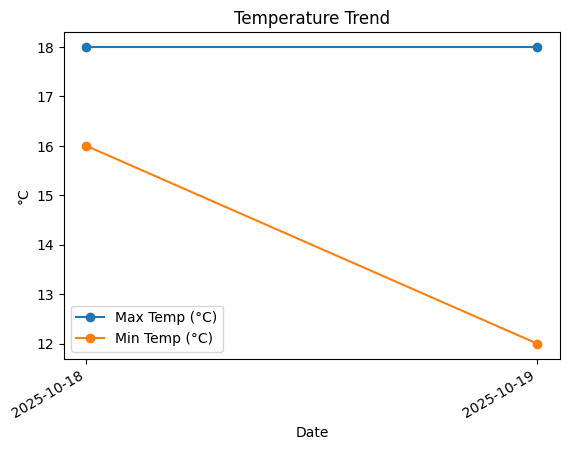

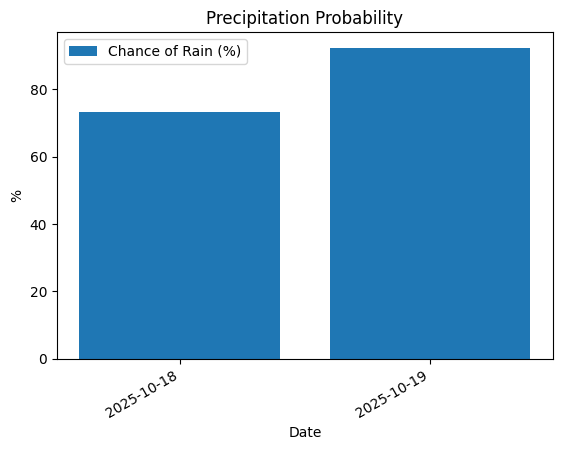

In [ ]:
# Example: programmatic usage without interactive menu
# from weather_data import get_weather_data
# from nlp import parse_weather_question
# from visuals import create_temperature_visualisation, create_precipitation_visualisation
# from ui import generate_weather_response, summarise

# Try a quick fetch (falls back to mock if offline)
demo_data = get_weather_data("Perth", forecast_days=2)
print("Summary:", summarise(demo_data))

parsed = parse_weather_question("Will it rain tomorrow in Perth?")
print("Parsed:", parsed)
print("Answer:", generate_weather_response(parsed, demo_data))

# Create charts (display in notebook)
create_temperature_visualisation(demo_data, output_type='display')
create_precipitation_visualisation(demo_data, output_type='display')

# Testing and Examples

<a id='testing'></a>
Unit-test-like checks and edge cases.

In [ ]:
# from weather_data import get_weather_data

# Edge case: invalid location (should raise ValueError)
try:
    data = get_weather_data("", 3)
except Exception as e:
    print("Caught expected error for empty location:", e)

# Valid call but large days should clamp to 5
data = get_weather_data("Perth", 99)
print("Days returned:", len(data.get("weather", [])))

Caught expected error for empty location: location must be a non-empty string
Days returned: 3
